In [1]:
import gcinfo
import pandas as pd
import matplotlib.pyplot as plt

gcinfo.search_titles(query="non permanent by type")

Estimates of the number of non-permanent residents by type, quarterly
Non-permanent resident type by place of birth: Canada, provinces and territories, census metropolitan areas and census agglomerations with parts
Estimates of the number of non-permanent residents on July 1, by age and gender
Job permanency (permanent and temporary) by industry, monthly, unadjusted for seasonality
Estimates of non-permanent residents as of July 1st, by age and sex, inactive
Building permits, non-residential values by type of structure
Employment in the non-profit sector by type of worker
Employee wages by job permanency and union coverage, annual
Immigrants to Canada, by country of last permanent residence
Non-bank mortgages extended, by lender type, insurance status and mortgage characteristics
Non-bank mortgages outstanding, by lender type, insurance status and mortgage characteristics
Capital expenditures, non-residential tangible assets, by type of asset and geography
Capital expenditures, non-res

In [2]:
gcinfo.list_resources(gcinfo.search_datasets(query='title:"Estimates of the number of non-permanent residents by type, quarterly"')["results"][0])


=== Estimates of the number of non-permanent residents by type, quarterly ===
ID: f8f711fa-6b75-4178-a60c-23093c071fc8
Org: Statistics Canada | Statistique Canada
Notes: This table provides quarterly estimates of the number of non-permanent residents by type for Canada, provinces and territories.<br>...
URL: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1710012101
Citation: Statistics Canada. Table 17-10-0121-01 Estimates of the number of non-permanent residents by type, quarterly
DOI:      https://doi.org/10.25318/1710012101-eng
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100121-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100121-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/sdmx/17100121-SDMX.zip


In [3]:
df, df_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/17100121-eng.zip")

Using cached file: cache\17100121-eng.zip


In [4]:
df["GEO"].astype(str).unique()

array(['Canada', 'Newfoundland and Labrador', 'Prince Edward Island',
       'Nova Scotia', 'New Brunswick', 'Quebec', 'Ontario', 'Manitoba',
       'Saskatchewan', 'Alberta', 'British Columbia', 'Yukon',
       'Northwest Territories', 'Nunavut'], dtype=object)

In [5]:
df_canada = df[df["GEO"] == "Canada"]

In [6]:
df_canada.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-07,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1361855,NaN,NaN,NaN,0
1,2021-07,Canada,2021A000011124,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927591,1.2,168206,NaN,NaN,NaN,0
2,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927592,1.3,94311,NaN,NaN,NaN,0
3,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927593,1.4,1485,NaN,NaN,NaN,0
4,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927594,1.5,4094,NaN,NaN,NaN,0


In [7]:
"""
Non-permanent resident types
    Total, non-permanent residents
        Total, asylum claimants, protected persons and related groups
            Asylum claimants, protected persons and related groups with work permit only
            Asylum claimants, protected persons and related groups with study permit only
            Asylum claimants, protected persons and related groups with work and study permits
            Asylum claimants, protected persons and related groups without work or study permits
        Total, permit holders and their family members
            Work permit holders only
            Study permit holders only
            Work and study permit holders
            Other
""";

In [8]:
df_canada.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-07,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1361855,NaN,NaN,NaN,0
1,2021-07,Canada,2021A000011124,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927591,1.2,168206,NaN,NaN,NaN,0
2,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927592,1.3,94311,NaN,NaN,NaN,0
3,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927593,1.4,1485,NaN,NaN,NaN,0
4,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927594,1.5,4094,NaN,NaN,NaN,0


In [9]:
df_canada_asylum = df_canada[df_canada["Non-permanent resident types"].isin([
        "Asylum claimants, protected persons and related groups with work permit only",
        "Asylum claimants, protected persons and related groups with study permit only",
        "Asylum claimants, protected persons and related groups with work and study permits",
        "Asylum claimants, protected persons and related groups without work or study permits"
])]
df_canada_asylum["Non-permanent resident types"].astype(str).unique()

array(['Asylum claimants, protected persons and related groups with work permit only',
       'Asylum claimants, protected persons and related groups with study permit only',
       'Asylum claimants, protected persons and related groups with work and study permits',
       'Asylum claimants, protected persons and related groups without work or study permits'],
      dtype=object)

In [10]:
df_canada_asylum[["REF_DATE", "Non-permanent resident types", "VALUE"]]

,REF_DATE,Non-permanent resident types,VALUE
2,2021-07,"Asylum claimants, protected persons and relate...",94311
3,2021-07,"Asylum claimants, protected persons and relate...",1485
4,2021-07,"Asylum claimants, protected persons and relate...",4094
5,2021-07,"Asylum claimants, protected persons and relate...",68316
156,2021-10,"Asylum claimants, protected persons and relate...",88826
...,...,...,...
2777,2026-01,"Asylum claimants, protected persons and relate...",138080
2928,2026-04,"Asylum claimants, protected persons and relate...",369555
2929,2026-04,"Asylum claimants, protected persons and relate...",2360
2930,2026-04,"Asylum claimants, protected persons and relate...",24012


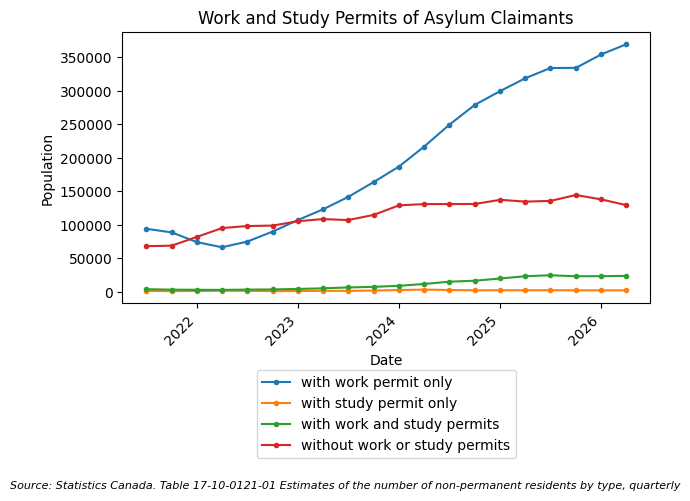

In [11]:
# Make sure REF_DATE is datetime
df = df_canada_asylum.copy()
df["REF_DATE"] = pd.to_datetime(df["REF_DATE"])

# The four types you listed
types = [
    "Asylum claimants, protected persons and related groups with work permit only",
    "Asylum claimants, protected persons and related groups with study permit only",
    "Asylum claimants, protected persons and related groups with work and study permits",
    "Asylum claimants, protected persons and related groups without work or study permits"
]

fig, ax = plt.subplots() # (figsize=(12, 6))

for t in types:
    subset = df[df["Non-permanent resident types"] == t]
    # Shorten the legend labels a bit for readability
    label = t.replace("Asylum claimants, protected persons and related groups ", "")
    ax.plot(subset["REF_DATE"], subset["VALUE"], marker=".", linestyle="solid", label=label)

ax.set_title("Work and Study Permits of Asylum Claimants")
ax.set_xlabel("Date")
ax.set_ylabel("Population")

# Legend below the plot
ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=1,
    frameon=True
)

# Source citation
plt.figtext(
    0.5, -0.03,
    "Source: Statistics Canada. Table 17-10-0121-01 Estimates of the number of non-permanent residents by type, quarterly",
    ha="center",
    fontsize=8,
    style="italic"
)

# Extra room at the bottom
plt.subplots_adjust(bottom=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# "Total, non-permanent residents"
df_canada_filtered = df_canada[df_canada["Non-permanent resident types"].isin(
    ["Total, asylum claimants, protected persons and related groups",
     "Total, permit holders and their family members"]
)][["REF_DATE", "Non-permanent resident types", "VALUE"]]
df_canada_filtered

,REF_DATE,Non-permanent resident types,VALUE
1,2021-07,"Total, asylum claimants, protected persons and...",168206
6,2021-07,"Total, permit holders and their family members",1193649
155,2021-10,"Total, asylum claimants, protected persons and...",162493
160,2021-10,"Total, permit holders and their family members",1280111
309,2022-01,"Total, asylum claimants, protected persons and...",161105
314,2022-01,"Total, permit holders and their family members",1252601
463,2022-04,"Total, asylum claimants, protected persons and...",166780
468,2022-04,"Total, permit holders and their family members",1281010
617,2022-07,"Total, asylum claimants, protected persons and...",178573
622,2022-07,"Total, permit holders and their family members",1407997


In [13]:
df_canada_filtered_pivot = df_canada_filtered.pivot(
    index="REF_DATE",
    columns="Non-permanent resident types",
    values="VALUE"
)
df_canada_filtered_pivot

Non-permanent resident types,"Total, asylum claimants, protected persons and related groups","Total, permit holders and their family members"
REF_DATE,,
2021-07,168206,1193649
2021-10,162493,1280111
2022-01,161105,1252601
2022-04,166780,1281010
2022-07,178573,1407997
2022-10,194063,1606770
2023-01,218865,1733552
2023-04,238951,1813953
2023-07,257383,2000712


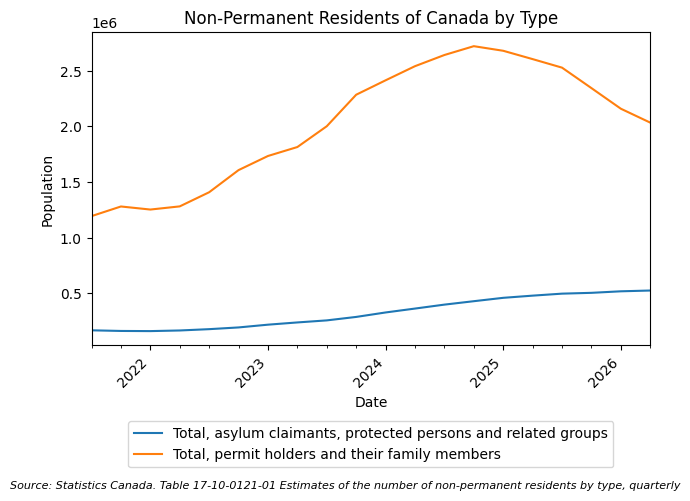

In [14]:
# Convert the index to real datetime first (if you haven’t already)
df_canada_filtered_pivot.index = pd.to_datetime(df_canada_filtered_pivot.index)

ax = df_canada_filtered_pivot.plot()

plt.title("Non-Permanent Residents of Canada by Type")
plt.xlabel("Date")
plt.ylabel("Population")

# Legend below the plot
ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=1,
    frameon=True
)

# Source citation (moved lower)
plt.figtext(
    0.5, -0.03,   # lowered from 0.01 to -0.02
    "Source: Statistics Canada. Table 17-10-0121-01 Estimates of the number of non-permanent residents by type, quarterly",
    ha="center",
    fontsize=8,
    style="italic"
)

# Extra room at the bottom
plt.subplots_adjust(bottom=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()